In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhuvankumarapatri/brain-tumor")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bhuvankumarapatri/brain-tumor


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch import amp

from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import KFold
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    matthews_corrcoef, 
    average_precision_score
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
DATA_DIR = os.path.join(path, "Training")
TEST_DIR = os.path.join(path, "Testing") 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Exact same augmentation used in the AO-ConvNeXt discovery phase
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
print(f"Total images for 5-Fold CV: {len(full_dataset)}")
print(f"Classes: {class_names}")

Total images for 5-Fold CV: 5712
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


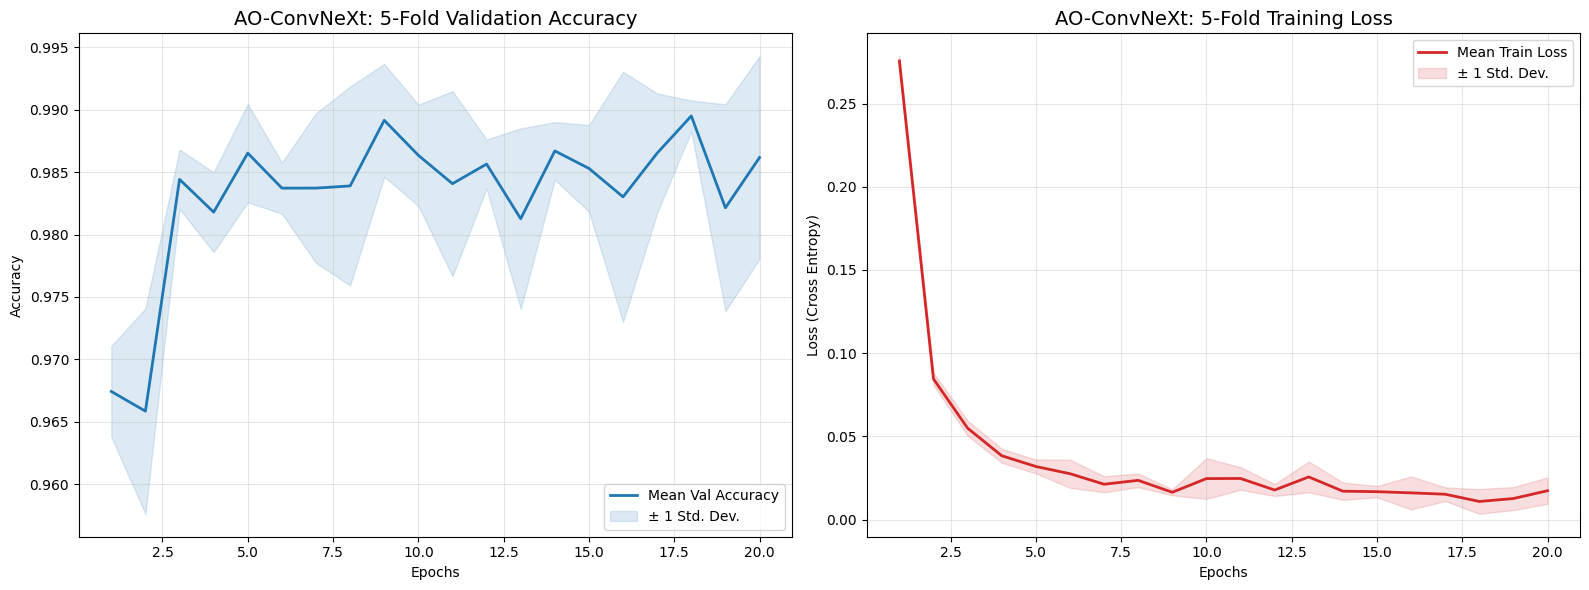

In [6]:
plt.figure(figsize=(16, 6))

# --- Plot 1: Accuracy Curve ---
plt.subplot(1, 2, 1)
mean_acc_curve = np.mean(all_folds_val_acc, axis=0)
std_acc_curve = np.std(all_folds_val_acc, axis=0)
epochs_range = np.arange(1, NUM_EPOCHS + 1)

plt.plot(epochs_range, mean_acc_curve, label='Mean Val Accuracy', color='#1f77b4', lw=2)
plt.fill_between(epochs_range, 
                 mean_acc_curve - std_acc_curve, 
                 mean_acc_curve + std_acc_curve, 
                 color='#1f77b4', alpha=0.15, label='± 1 Std. Dev.')

plt.title('AO-ConvNeXt: 5-Fold Validation Accuracy', fontsize=14)
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)

# --- Plot 2: Training Loss Curve ---
plt.subplot(1, 2, 2)
mean_loss_curve = np.mean(all_folds_train_loss, axis=0)
std_loss_curve = np.std(all_folds_train_loss, axis=0)

plt.plot(epochs_range, mean_loss_curve, label='Mean Train Loss', color='#d62728', lw=2)
plt.fill_between(epochs_range, 
                 mean_loss_curve - std_loss_curve, 
                 mean_loss_curve + std_loss_curve, 
                 color='#d62728', alpha=0.15, label='± 1 Std. Dev.')

plt.title('AO-ConvNeXt: 5-Fold Training Loss', fontsize=14)
plt.xlabel('Epochs'); plt.ylabel('Loss (Cross Entropy)'); plt.legend(loc='upper right'); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
from tqdm import tqdm
import time

# 🎯 AO-OPTIMIZED HYPERPARAMETERS
BEST_LR = 1.3320e-04
BEST_DROPOUT = 0.2693
BEST_BATCH_SIZE = 26
NUM_EPOCHS = 20

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
all_folds_val_acc = [] 
all_folds_train_loss = [] # Added for complete history tracking
start_time = time.time()
global_best_acc = 0.0
final_model_path = "best_ao_convnext_final.pth"

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n" + "═"*50 + f"\n 🚀 STARTING FOLD {fold+1}/5 \n" + "═"*50)
    
    # Subset definitions
    train_sub = Subset(datasets.ImageFolder(DATA_DIR, transform=train_transform), train_idx)
    val_sub = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transform), val_idx)
    
    train_loader = DataLoader(train_sub, batch_size=BEST_BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_sub, batch_size=BEST_BATCH_SIZE, shuffle=False, num_workers=2)
    
    # Model Initialization
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    for m in model.classifier.modules():
        if isinstance(m, nn.Dropout): m.p = BEST_DROPOUT
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 4)
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=BEST_LR)
    criterion = nn.CrossEntropyLoss()
    scaler = amp.GradScaler('cuda') 

    current_fold_acc_history = []
    current_fold_loss_history = []
    best_fold_acc = 0.0
    
    for epoch in range(NUM_EPOCHS):
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{NUM_EPOCHS}", unit="batch", leave=False)
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
            
        # --- VALIDATION PHASE ---
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (pred == labels).sum().item()
        
        val_acc = val_correct / val_total
        current_fold_acc_history.append(val_acc)
        current_fold_loss_history.append(epoch_train_loss)
        
        # Build Status Message
        status_msg = f"Epoch {epoch+1} | Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {val_acc:.4f}"
        
        if val_acc > best_fold_acc:
            best_fold_acc = val_acc
            if val_acc > global_best_acc:
                global_best_acc = val_acc
                torch.save(model.state_dict(), final_model_path)
                status_msg += " ✅ Best model saved"
        
        print(status_msg)
    
    print(f"\n✅ Fold {fold+1} Peak Accuracy: {best_fold_acc:.4f}")
    fold_results.append(best_fold_acc)
    all_folds_val_acc.append(current_fold_acc_history)
    all_folds_train_loss.append(current_fold_loss_history)

# Final Statistics
total_duration = (time.time() - start_time) / 60
print("\n" + "⭐"*50)
print(f"🎯 5-FOLD MEAN ACCURACY: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
print(f"🕒 TOTAL EXECUTION TIME: {total_duration:.2f} mins")
print("⭐"*50)


══════════════════════════════════════════════════
 🚀 STARTING FOLD 1/5 
══════════════════════════════════════════════════
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 210MB/s] 


Epoch 1 | Loss: 0.2715 | Train Acc: 0.8976 | Val Acc: 0.9650 ✅ Best model saved


Epoch 2 | Loss: 0.0898 | Train Acc: 0.9685 | Val Acc: 0.9755 ✅ Best model saved


Epoch 3 | Loss: 0.0471 | Train Acc: 0.9860 | Val Acc: 0.9869 ✅ Best model saved


...

Epoch 16 | Loss: 0.0182 | Train Acc: 0.9932 | Val Acc: 0.9667


Epoch 17 | Loss: 0.0138 | Train Acc: 0.9950 | Val Acc: 0.9904


Epoch 18 | Loss: 0.0045 | Train Acc: 0.9989 | Val Acc: 0.9895


Epoch 19 | Loss: 0.0042 | Train Acc: 0.9985 | Val Acc: 0.9886


Epoch 20 | Loss: 0.0210 | Train Acc: 0.9941 | Val Acc: 0.9912

✅ Fold 5 Peak Accuracy: 0.9912

⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
🎯 5-FOLD MEAN ACCURACY: 0.9921 ± 0.0012
🕒 TOTAL EXECUTION TIME: 53.47 mins
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐


In [7]:
best_model = convnext_tiny()
best_model.classifier[2] = nn.Linear(best_model.classifier[2].in_features, 4)
best_model.load_state_dict(torch.load(final_model_path))
best_model = best_model.to(device).eval()

y_true, y_probs, y_pred = [], [], []
with torch.no_grad():
    for images, labels in val_loader: 
        images, labels = images.to(device), labels.to(device)
        logits = best_model(images)
        y_true.extend(labels.cpu().numpy()); y_probs.extend(F.softmax(logits, dim=1).cpu().numpy())
        y_pred.extend(torch.max(logits, 1)[1].cpu().numpy())

y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
aps = [average_precision_score(y_true_bin[:, i], np.array(y_probs)[:, i]) for i in range(4)]
print(f"\n🎯 MEAN AVERAGE PRECISION (mAP): {np.mean(aps):.4f}")
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


🎯 MEAN AVERAGE PRECISION (mAP): 1.0000

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000       244
  meningioma     1.0000    0.9960    0.9980       249
     notumor     1.0000    1.0000    1.0000       348
   pituitary     0.9967    1.0000    0.9983       301

    accuracy                         0.9991      1142
   macro avg     0.9992    0.9990    0.9991      1142
weighted avg     0.9991    0.9991    0.9991      1142



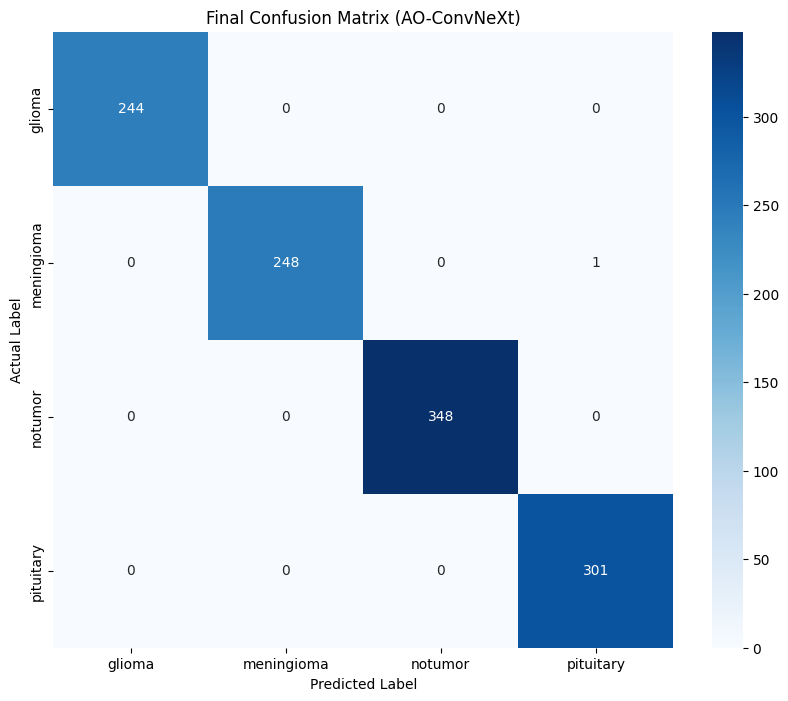

Matthews Correlation Coefficient (MCC): 0.9988


In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final Confusion Matrix (AO-ConvNeXt)')
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label'); plt.show()
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_true, y_pred):.4f}")

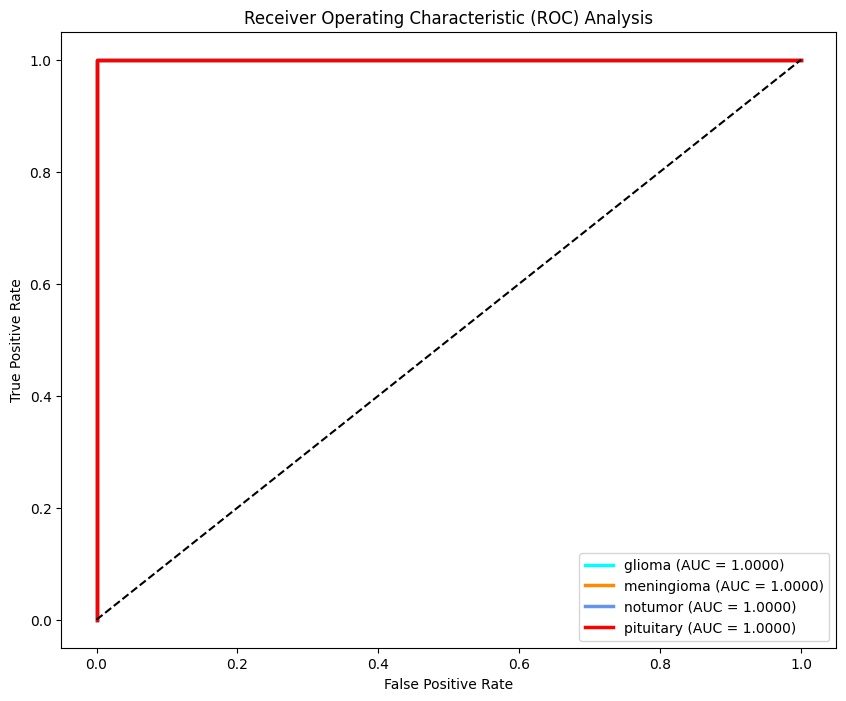

🏆 AVERAGE ROC-AUC: 1.0000


In [9]:
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red']
for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5, label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5); plt.title('Receiver Operating Characteristic (ROC) Analysis')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(loc="lower right"); plt.show()
print(f"🏆 AVERAGE ROC-AUC: {np.mean(list(roc_auc.values())):.4f}")

🚀 Evaluating AO-ConvNeXt on 1311 images (Batch Size: 26)...


100%|██████████| 51/51 [00:10<00:00,  4.75it/s]



════════════════════════════════════════════════════════════
🏆 FINAL RESULTS: AO-CONVNEXT (Batch Size: 26)
════════════════════════════════════════════════════════════
✅ TEST ACCURACY : 99.47%
✅ MCC           : 0.9928
✅ mAP           : 0.9998
✅ AUC-ROC       : 0.9999
------------------------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9966    0.9867    0.9916       300
  meningioma     0.9935    1.0000    0.9967       306
     notumor     0.9951    0.9975    0.9963       405
   pituitary     0.9933    0.9933    0.9933       300

    accuracy                         0.9947      1311
   macro avg     0.9946    0.9944    0.9945      1311
weighted avg     0.9947    0.9947    0.9947      1311



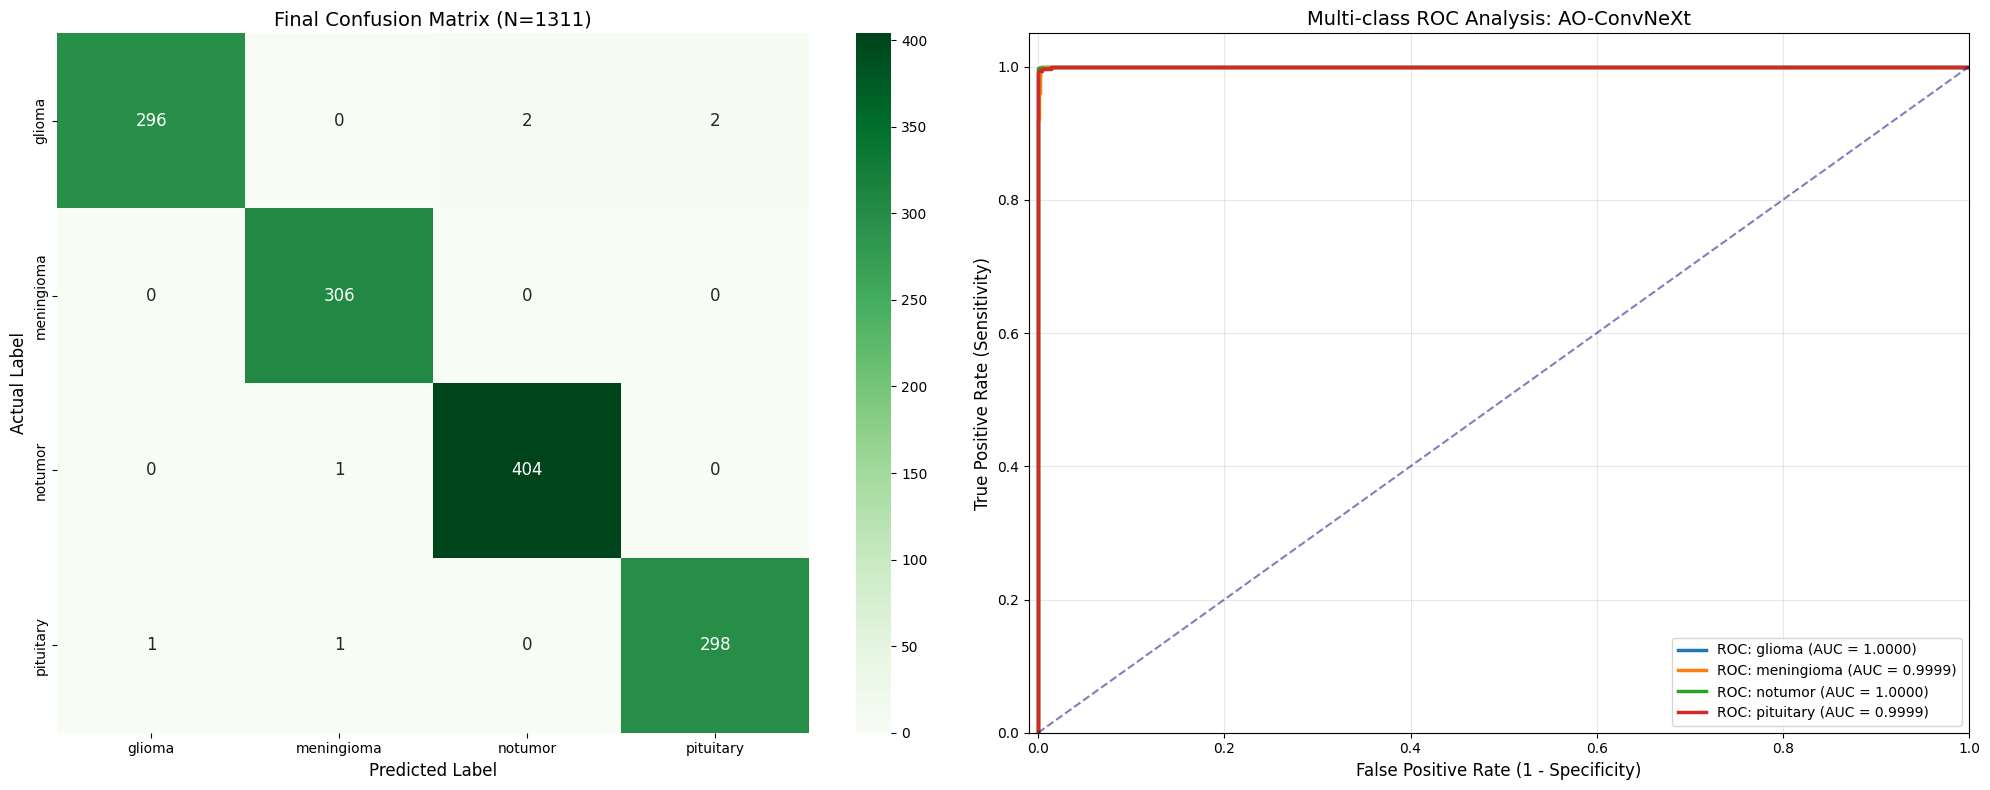

In [14]:
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef, average_precision_score, 
    roc_auc_score, classification_report, roc_curve, auc, confusion_matrix
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# --- 1. CONFIGURATION ---
BEST_BATCH_SIZE_AO = 26  
TEST_DIR = os.path.join(path, "Testing")

# --- 2. DATA LOADING ---
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BEST_BATCH_SIZE_AO, shuffle=False)

# --- 3. MODEL LOADING ---
model.load_state_dict(torch.load("best_ao_convnext_final.pth"))
model.eval()

y_true_final = []
y_pred_final = []
y_probs_final = []

# --- 4. INFERENCE ---
print(f"🚀 Evaluating AO-ConvNeXt on {len(test_dataset)} images (Batch Size: {BEST_BATCH_SIZE_AO})...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        y_true_final.extend(labels.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())
        y_probs_final.extend(probs.cpu().numpy())

# Convert to arrays
y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)
y_probs_final = np.array(y_probs_final)
y_true_bin = label_binarize(y_true_final, classes=[0, 1, 2, 3])

# --- 5. CALCULATE METRICS ---
acc = accuracy_score(y_true_final, y_pred_final) * 100
mcc = matthews_corrcoef(y_true_final, y_pred_final)
map_score = average_precision_score(y_true_bin, y_probs_final, average='macro')
auc_macro = roc_auc_score(y_true_bin, y_probs_final, multi_class='ovr', average='macro')

# --- 6. MASTER PRINTOUT ---
print("\n" + "═"*60)
print(f"🏆 FINAL RESULTS: AO-CONVNEXT (Batch Size: {BEST_BATCH_SIZE_AO})")
print("═"*60)
print(f"✅ TEST ACCURACY : {acc:.2f}%")
print(f"✅ MCC           : {mcc:.4f}")
print(f"✅ mAP           : {map_score:.4f}")
print(f"✅ AUC-ROC       : {auc_macro:.4f}")
print("-" * 60)
print(classification_report(y_true_final, y_pred_final, target_names=class_names, digits=4))

# --- 7. VISUALIZATIONS ---
plt.figure(figsize=(20, 8))

# --- PLOT 1: CONFUSION MATRIX ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true_final, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12}, cbar=True)
plt.title(f'Final Confusion Matrix (N={len(test_dataset)})', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# --- PLOT 2: ROC-AUC CURVE ---
plt.subplot(1, 2, 2)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_final[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2.5,
             label=f'ROC: {class_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', alpha=0.5)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'Multi-class ROC Analysis: AO-ConvNeXt', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()